# 10_understand_panderm_full_finetune_baseline4

This notebook is a **walk-through notebook** for **Baseline 4: Official PanDerm full fine-tuning**.

It is based on:
- `scripts/run_panderm_full_finetune_official.py`
- `external/PanDerm/classification/run_class_finetuning.py`
- helper files such as `datasets/derm_data.py`, `furnace/optim_factory.py`, and `furnace/utils.py`

The goal is **understanding the full training pipeline step by step**.

## What this notebook shows
1. How your wrapper script builds and launches the official training command
2. How the official CSV is read and split into train / val / test
3. How the official transforms differ between train and eval
4. How the weighted sampler is built
5. How PanDerm full fine-tuning model is built and initialized from pretrained backbone weights
6. How one batch flows through the model
7. How parameter groups, layer decay, and weight decay are assigned
8. What the optimizer and criterion are
9. Where backpropagation happens in baseline 4
10. Why this baseline is different from baselines 1–3
11. How checkpoint selection and final evaluation work conceptually


In [1]:
from pathlib import Path
import json
import random
import sys
import warnings
import copy
import shlex
from types import SimpleNamespace

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.layers is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'Importing from timm\.models\.registry is deprecated.*',
    category=FutureWarning,
)
warnings.filterwarnings(
    'ignore',
    message=r'torch\.meshgrid: in an upcoming release.*',
    category=UserWarning,
)

## Config

Choose HAM or BCN by changing the CSV / image root / number of classes.

This notebook focuses on the **official full fine-tuning baseline**.
Unlike baselines 1–3, here the **entire PanDerm model is trained**, not only a probe on frozen features.

In [2]:
REPO_ROOT = Path('..').resolve()
PANDERM_CLASSIFICATION_DIR = (REPO_ROOT / 'external' / 'PanDerm' / 'classification').resolve()
if str(PANDERM_CLASSIFICATION_DIR) not in sys.path:
    sys.path.insert(0, str(PANDERM_CLASSIFICATION_DIR))

from models.modeling_finetune import panderm_base_patch16_224_finetune  # type: ignore
from datasets.derm_data import Uni_Dataset  # type: ignore
from furnace.optim_factory import create_optimizer, LayerDecayValueAssigner, get_parameter_groups  # type: ignore
import furnace.utils as furnace_utils  # type: ignore

CSV_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'HAM10000.csv'
ROOT_PATH = REPO_ROOT / 'data' / 'HAM10000' / 'images'
CLASS_NAMES_ARG = 'akiec,bcc,bkl,df,mel,nv,vasc'
NB_CLASSES = 7

# CSV_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'bcn20000.csv'
# ROOT_PATH = REPO_ROOT / 'data' / 'BCN20000' / 'images'
# CLASS_NAMES_ARG = 'actinic keratosis,basal cell carcinoma,melanoma,nevus,seborrheic keratosis,solar lentigo,squamous cell carcinoma,dermatofibroma,vascular lesion'
# NB_CLASSES = 9

PRETRAINED_CHECKPOINT = REPO_ROOT / 'external' / 'weights' / 'panderm_bb_data6_checkpoint-499.pth'
OUTPUT_DIR = REPO_ROOT / 'outputs' / 'panderm_full_finetune_understanding'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'PanDerm_Base_FT'
IMAGE_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 50
LR = 5e-4
WEIGHT_DECAY = 0.05
WARMUP_EPOCHS = 10
LAYER_DECAY = 0.65
DROP_PATH = 0.2
UPDATE_FREQ = 1
SEED = 0
NUM_WORKERS = 0
MONITOR = 'recall'
USE_WEIGHTED_SAMPLER = True
USE_TTA = False

BEST_FINETUNED_CKPT = OUTPUT_DIR / 'checkpoint-best.pth'  # optional: only if you already trained baseline 4 here

if torch.cuda.is_available():
    DEVICE = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

print('DEVICE:', DEVICE)
print('CSV_PATH exists:', CSV_PATH.exists(), CSV_PATH)
print('ROOT_PATH exists:', ROOT_PATH.exists(), ROOT_PATH)
print('PRETRAINED_CHECKPOINT exists:', PRETRAINED_CHECKPOINT.exists(), PRETRAINED_CHECKPOINT)
print('BEST_FINETUNED_CKPT exists:', BEST_FINETUNED_CKPT.exists(), BEST_FINETUNED_CKPT)

DEVICE: mps
CSV_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv
ROOT_PATH exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images
PRETRAINED_CHECKPOINT exists: True /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth
BEST_FINETUNED_CKPT exists: False /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_full_finetune_understanding/checkpoint-best.pth


In [3]:
def seed_everything(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)
print('Seeded with:', SEED)

Seeded with: 0


## 1. Your wrapper script logic

Your script `run_panderm_full_finetune_official.py` is mainly a **launcher / wrapper**.

It does **not** implement the training loop itself.
Instead, it:
1. parses convenient arguments
2. builds the official command
3. calls `external/PanDerm/classification/run_class_finetuning.py`
4. optionally calls it again in `--eval` mode


In [4]:
wrapper_args = {
    'panderm_classification_dir': str(PANDERM_CLASSIFICATION_DIR),
    'csv_path': str(CSV_PATH),
    'root_path': str(ROOT_PATH),
    'pretrained_checkpoint': str(PRETRAINED_CHECKPOINT),
    'output_dir': str(OUTPUT_DIR),
    'model': MODEL_NAME,
    'nb_classes': NB_CLASSES,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
    'lr': LR,
    'weight_decay': WEIGHT_DECAY,
    'warmup_epochs': WARMUP_EPOCHS,
    'layer_decay': LAYER_DECAY,
    'drop_path': DROP_PATH,
    'update_freq': UPDATE_FREQ,
    'seed': SEED,
    'num_workers': NUM_WORKERS,
    'monitor': MONITOR,
    'weights': USE_WEIGHTED_SAMPLER,
    'tta': USE_TTA,
    'wandb_name': 'panderm_full_finetune',
    'wandb_mode': 'disabled',
    'device': DEVICE,
}
print(json.dumps(wrapper_args, indent=2))

{
  "panderm_classification_dir": "/Users/choekyelnyungmartsang/Developer/master-thesis/external/PanDerm/classification",
  "csv_path": "/Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv",
  "root_path": "/Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images",
  "pretrained_checkpoint": "/Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth",
  "output_dir": "/Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_full_finetune_understanding",
  "model": "PanDerm_Base_FT",
  "nb_classes": 7,
  "batch_size": 32,
  "epochs": 50,
  "lr": 0.0005,
  "weight_decay": 0.05,
  "warmup_epochs": 10,
  "layer_decay": 0.65,
  "drop_path": 0.2,
  "update_freq": 1,
  "seed": 0,
  "num_workers": 0,
  "monitor": "recall",
  "weights": true,
  "tta": false,
  "wandb_name": "panderm_full_finetune",
  "wandb_mode": "disabled",
  "device": "mps"
}


In [5]:
def quote_cmd(cmd):
    return ' '.join(shlex.quote(str(x)) for x in cmd)

official_script = PANDERM_CLASSIFICATION_DIR / 'run_class_finetuning.py'

train_cmd = [
    sys.executable,
    str(official_script),
    '--model', MODEL_NAME,
    '--pretrained_checkpoint', str(PRETRAINED_CHECKPOINT),
    '--nb_classes', str(NB_CLASSES),
    '--batch_size', str(BATCH_SIZE),
    '--lr', str(LR),
    '--update_freq', str(UPDATE_FREQ),
    '--warmup_epochs', str(WARMUP_EPOCHS),
    '--epochs', str(EPOCHS),
    '--layer_decay', str(LAYER_DECAY),
    '--drop_path', str(DROP_PATH),
    '--weight_decay', str(WEIGHT_DECAY),
    '--mixup', '0.8',
    '--cutmix', '1.0',
    '--sin_pos_emb',
    '--no_auto_resume',
    '--monitor', MONITOR,
    '--imagenet_default_mean_and_std',
    '--output_dir', str(OUTPUT_DIR),
    '--csv_path', str(CSV_PATH),
    '--root_path', str(ROOT_PATH),
    '--wandb_name', 'panderm_full_finetune',
    '--seed', str(SEED),
    '--device', str(DEVICE),
    '--num_workers', str(NUM_WORKERS),
]

if USE_WEIGHTED_SAMPLER:
    train_cmd.append('--weights')

print('TRAIN COMMAND:')
print(quote_cmd(train_cmd))

TRAIN COMMAND:
/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/bin/python /Users/choekyelnyungmartsang/Developer/master-thesis/external/PanDerm/classification/run_class_finetuning.py --model PanDerm_Base_FT --pretrained_checkpoint /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth --nb_classes 7 --batch_size 32 --lr 0.0005 --update_freq 1 --warmup_epochs 10 --epochs 50 --layer_decay 0.65 --drop_path 0.2 --weight_decay 0.05 --mixup 0.8 --cutmix 1.0 --sin_pos_emb --no_auto_resume --monitor recall --imagenet_default_mean_and_std --output_dir /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_full_finetune_understanding --csv_path /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv --root_path /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images --wandb_name panderm_full_finetune --seed 0 --device mps --num_workers 0 --weights


## 2. Load CSV and inspect splits

In [6]:
df = pd.read_csv(CSV_PATH, low_memory=False)
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())

split_series = df['split'].astype(str).str.lower()
train_df = df[split_series == 'train'].copy()
val_df = df[split_series == 'val'].copy()
test_df = df[split_series == 'test'].copy()

print('train_df:', train_df.shape)
print('val_df:', val_df.shape)
print('test_df:', test_df.shape)

print('\nTrain label counts:')
print(train_df['label'].value_counts().sort_index())
print('\nVal label counts:')
print(val_df['label'].value_counts().sort_index())
print('\nTest label counts:')
print(test_df['label'].value_counts().sort_index())

Shape: (10015, 13)
Columns: ['lesion_id', 'image_id', 'dx', 'dx_type', 'age', 'sex', 'localization', 'dataset', 'split', 'label', 'image', 'binary_label', 'age_group']


,lesion_id,image_id,dx,dx_type,age,sex,localization,dataset,split,label,image,binary_label,age_group
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0027419.jpg,0,old
1,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0026769.jpg,0,old
2,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,vidir_modern,train,2,ISIC_0025661.jpg,0,old
3,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0031633.jpg,0,old
4,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear,vidir_modern,train,2,ISIC_0027850.jpg,0,old


train_df: (8207, 13)
val_df: (575, 13)
test_df: (1232, 13)

Train label counts:
label
0     273
1     448
2     941
3     102
4    1021
5    5304
6     118
Name: count, dtype: int64

Val label counts:
label
0     19
1     22
2     50
3      5
4     22
5    450
6      7
Name: count, dtype: int64

Test label counts:
label
0     35
1     44
2    107
3      8
4     70
5    951
6     17
Name: count, dtype: int64


## 3. Build class-name mapping

In [7]:
def make_class_name_map(class_names_arg, label_ids):
    names = [x.strip() for x in class_names_arg.split(',')]
    mapping = {}
    for i in label_ids:
        mapping[i] = names[i] if i < len(names) else str(i)
    return mapping

all_label_ids = sorted(set(train_df['label'].astype(int)) | set(val_df['label'].astype(int)) | set(test_df['label'].astype(int)))
CLASS_NAME_MAP = make_class_name_map(CLASS_NAMES_ARG, all_label_ids)
display(pd.DataFrame({
    'class_id': list(CLASS_NAME_MAP.keys()),
    'class_name': list(CLASS_NAME_MAP.values()),
}))

,class_id,class_name
0,0,akiec
1,1,bcc
2,2,bkl
3,3,df
4,4,mel
5,5,nv
6,6,vasc


## 4. One example image

lesion_id            HAM_0006071
image_id            ISIC_0032343
dx                           bkl
dx_type                    histo
age                         70.0
sex                       female
localization                face
dataset             vidir_modern
split                       test
label                          2
image           ISIC_0032343.jpg
binary_label                   0
age_group                    old
Name: 8783, dtype: object

Example path: /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images/ISIC_0032343.jpg
Original PIL size: (600, 450)


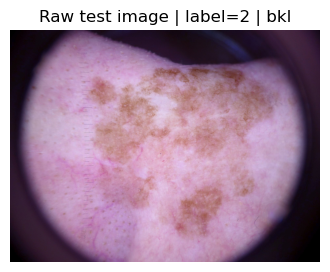

In [8]:
example_row = test_df.iloc[0].copy()
example_path = ROOT_PATH / str(example_row['image'])
print(example_row)
print('\nExample path:', example_path)

with Image.open(example_path) as img:
    img_rgb = img.convert('RGB')
    print('Original PIL size:', img_rgb.size)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(f"Raw test image | label={example_row['label']} | {CLASS_NAME_MAP[int(example_row['label'])]}")
    plt.axis('off')
    plt.show()

## 5. Train vs eval transforms

This cell shows a **representative approximation** of the transform logic used in the official full fine-tuning baseline.

It is useful for understanding the idea:
- train transform uses stronger augmentation
- val/test transform is more stable and deterministic

But this cell is **not guaranteed to be an exact line-by-line mirror** of the official PanDerm transform builder.
For exact reproduction, always trust the official training script and its helper code.

Train transform tensor shape: (3, 224, 224)
Eval transform tensor shape: (3, 224, 224)


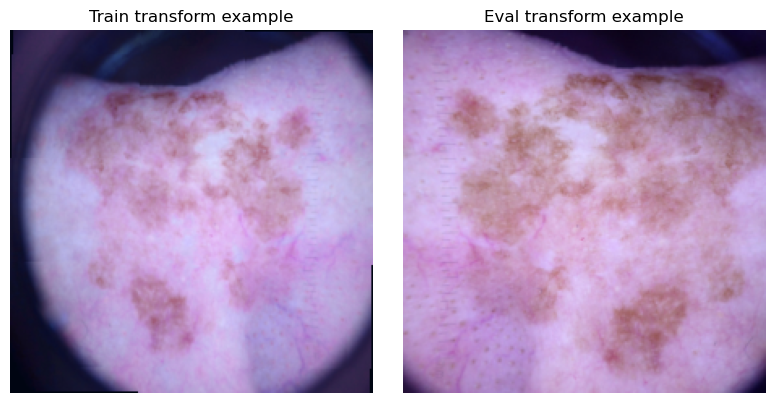

In [9]:
mean = [0.485, 0.456, 0.406]
std = [0.228, 0.224, 0.225]
normalize = transforms.Normalize(mean=mean, std=std)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(45),
    transforms.ColorJitter(hue=0.2),
    transforms.ToTensor(),
    normalize,
])

val_test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    normalize,
])

train_tensor = train_transform(img_rgb)
eval_tensor = val_test_transform(img_rgb)

print('Train transform tensor shape:', tuple(train_tensor.shape))
print('Eval transform tensor shape:', tuple(eval_tensor.shape))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, tensor, title in zip(axes, [train_tensor, eval_tensor], ['Train transform example', 'Eval transform example']):
    vis = tensor.permute(1, 2, 0).cpu().numpy()
    vis = (vis - vis.min()) / (vis.max() - vis.min() + 1e-8)
    ax.imshow(vis)
    ax.set_title(title)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 6. Build official datasets

The official `Uni_Dataset` filters rows by split internally and returns:
- image tensor
- filename
- label


In [10]:
dataset_train = Uni_Dataset(
    df=df,
    root=ROOT_PATH,
    train=True,
    transforms=train_transform,
    binary=False,
    image_key='image',
)
dataset_val = Uni_Dataset(
    df=df,
    root=ROOT_PATH,
    val=True,
    transforms=val_test_transform,
    binary=False,
    image_key='image',
)
dataset_test = Uni_Dataset(
    df=df,
    root=ROOT_PATH,
    test=True,
    transforms=val_test_transform,
    binary=False,
    image_key='image',
)

print('len(dataset_train):', len(dataset_train))
print('len(dataset_val):', len(dataset_val))
print('len(dataset_test):', len(dataset_test))

x0, fname0, y0 = dataset_train[0]
print('One dataset item:')
print('  image tensor shape:', tuple(x0.shape))
print('  filename:', fname0)
print('  label:', y0, CLASS_NAME_MAP[int(y0)])

len(dataset_train): 8207
len(dataset_val): 575
len(dataset_test): 1232
One dataset item:
  image tensor shape: (3, 224, 224)
  filename: ISIC_0027419.jpg
  label: 2 bkl


## 7. Weighted sampler

When `--weights` is enabled, the official code builds a `WeightedRandomSampler` from the train split label distribution.

This is important for imbalanced dermatology datasets.

In [11]:
label_counts = dataset_train.count_label()
total_samples = int(label_counts.sum())
weights = [total_samples / (len(label_counts) * count) for count in label_counts]
weight_dict = dict(zip(label_counts.index.tolist(), weights))

display(pd.DataFrame({
    'class_id': label_counts.index.tolist(),
    'class_name': [CLASS_NAME_MAP[int(i)] for i in label_counts.index.tolist()],
    'count': label_counts.tolist(),
    'sample_weight': weights,
}))

train_y = df[df['split'] == 'train']['label'].astype(int).values.tolist()
sample_weights = torch.tensor([weight_dict[label] for label in train_y], dtype=torch.float32)
weighted_sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(dataset_train),
    replacement=True,
)

print('Weighted sampler created:', type(weighted_sampler).__name__)
print('Number of sample weights:', len(sample_weights))

,class_id,class_name,count,sample_weight
0,0,akiec,273,4.294610
1,1,bcc,448,2.617028
2,2,bkl,941,1.245939
3,3,df,102,11.494398
4,4,mel,1021,1.148314
5,5,nv,5304,0.221046
6,6,vasc,118,9.935835


Weighted sampler created: WeightedRandomSampler
Number of sample weights: 8207


In [12]:
train_loader = DataLoader(
    dataset_train,
    sampler=weighted_sampler if USE_WEIGHTED_SAMPLER else None,
    shuffle=False if USE_WEIGHTED_SAMPLER else True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
    drop_last=True,
)
val_loader = DataLoader(
    dataset_val,
    sampler=None,
    shuffle=False,
    batch_size=int(1.5 * BATCH_SIZE),
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
    drop_last=False,
)
test_loader = DataLoader(
    dataset_test,
    sampler=None,
    shuffle=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=(DEVICE == 'cuda'),
    drop_last=False,
)

batch_images, batch_filenames, batch_labels = next(iter(train_loader))
print('Train batch image shape:', tuple(batch_images.shape))
print('Train batch filenames length:', len(batch_filenames))
print('Train batch labels shape:', tuple(batch_labels.shape))
print('First 5 labels:', batch_labels[:5].tolist())

Train batch image shape: (32, 3, 224, 224)
Train batch filenames length: 32
Train batch labels shape: (32,)
First 5 labels: [6, 3, 5, 0, 3]


## 8. Build the official full fine-tuning model

This baseline is **not** a frozen encoder.

The model is built as `PanDerm_Base_FT`, which includes the full transformer and classifier head.
Then pretrained backbone weights are loaded into it.


In [13]:
model = panderm_base_patch16_224_finetune(
    pretrained=False,
    num_classes=NB_CLASSES,
    drop_rate=0.0,
    drop_path_rate=DROP_PATH,
    attn_drop_rate=0.0,
    drop_block_rate=None,
    use_mean_pooling=True,
    init_scale=0.001,
    use_rel_pos_bias=True,
    init_values=0.1,
    lin_probe=False,
)

print(model.__class__.__name__)
print('Patch size:', model.patch_embed.patch_size)
print('Number of blocks:', len(model.blocks))
print('Head:', model.head)

VisionTransformer
Patch size: (16, 16)
Number of blocks: 12
Head: Linear(in_features=768, out_features=7, bias=True)


## 9. Load pretrained backbone weights into the fine-tuning model

The official script does a non-trivial key remapping:
- keeps only keys starting with `encoder.`
- removes `decoder.` and `teacher.` keys
- renames `encoder.*` -> `*`
- may rename `norm.*` -> `fc_norm.*`
- removes mismatched head weights

Below we mirror the important logic in simplified form.

In [14]:
checkpoint_model_raw = torch.load(PRETRAINED_CHECKPOINT, map_location='cpu', weights_only=True)
checkpoint = {'model': checkpoint_model_raw}
checkpoint_model = checkpoint['model'].copy()

all_keys = list(checkpoint_model.keys())
encoder_keys = [k for k in all_keys if k.startswith('encoder.')]

# for key in encoder_keys:
#     new_key = key.replace('encoder.', '')
#     checkpoint_model[new_key] = checkpoint_model[key]
#     checkpoint_model.pop(key)

# for key in list(checkpoint_model.keys()):
#     if key.startswith('decoder.') or key.startswith('teacher.'):
#         checkpoint_model.pop(key)

for key in list(checkpoint_model.keys()):
    if key.startswith('norm.'):
        new_key = key.replace('norm.', 'fc_norm.')
        checkpoint_model[new_key] = checkpoint_model[key]
        checkpoint_model.pop(key)

state_dict = model.state_dict()
for k in ['head.weight', 'head.bias']:
    if k in checkpoint_model and k in state_dict and checkpoint_model[k].shape != state_dict[k].shape:
        print(f'Removing mismatched key: {k}')
        del checkpoint_model[k]

missing, unexpected = model.load_state_dict(checkpoint_model, strict=False)
print('Missing keys:', len(missing))
print('First missing keys:', missing[:20])
print('Unexpected keys:', len(unexpected))
print('First unexpected keys:', unexpected[:20])

Missing keys: 26
First missing keys: ['blocks.0.attn.relative_position_bias_table', 'blocks.0.attn.relative_position_index', 'blocks.1.attn.relative_position_bias_table', 'blocks.1.attn.relative_position_index', 'blocks.2.attn.relative_position_bias_table', 'blocks.2.attn.relative_position_index', 'blocks.3.attn.relative_position_bias_table', 'blocks.3.attn.relative_position_index', 'blocks.4.attn.relative_position_bias_table', 'blocks.4.attn.relative_position_index', 'blocks.5.attn.relative_position_bias_table', 'blocks.5.attn.relative_position_index', 'blocks.6.attn.relative_position_bias_table', 'blocks.6.attn.relative_position_index', 'blocks.7.attn.relative_position_bias_table', 'blocks.7.attn.relative_position_index', 'blocks.8.attn.relative_position_bias_table', 'blocks.8.attn.relative_position_index', 'blocks.9.attn.relative_position_bias_table', 'blocks.9.attn.relative_position_index']
Unexpected keys: 0
First unexpected keys: []


# *Note*
- `'blocks.0.attn.relative_position_bias_table', 'blocks.0.attn.relative_position_index',`...`'blocks.11.attn.relative_position_bias_table', 'blocks.11.attn.relative_position_index',` is missing from the checkpoint.

In [16]:
model = model.to(DEVICE)
model.train()

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params: {total_params:,}')
print(f'Trainable params: {trainable_params:,}')
print('Important: in baseline 4, these trainable parameters are actually updated during training.')

Total params: 85,918,663
Trainable params: 85,767,367
Important: in baseline 4, these trainable parameters are actually updated during training.


## 10. Forward hooks: what happens in one full forward pass

In [17]:
shape_log = []
hooks = []

def register_shape_hook(module, name):
    def hook(module, inputs, output):
        in_shape = []
        for x in inputs:
            if torch.is_tensor(x):
                in_shape.append(tuple(x.shape))
            else:
                in_shape.append(type(x).__name__)

        if torch.is_tensor(output):
            out_shape = tuple(output.shape)
        elif isinstance(output, tuple):
            out_shape = [tuple(o.shape) if torch.is_tensor(o) else type(o).__name__ for o in output]
        else:
            out_shape = type(output).__name__

        shape_log.append({'module': name, 'input_shape': in_shape, 'output_shape': out_shape})
    return module.register_forward_hook(hook)

if getattr(model, 'patch_embed', None) is not None:
    hooks.append(register_shape_hook(model.patch_embed, 'patch_embed'))
if getattr(model, 'blocks', None) is not None and len(model.blocks) > 0:
    hooks.append(register_shape_hook(model.blocks[0], 'block_0'))
    hooks.append(register_shape_hook(model.blocks[-1], 'block_last'))
if getattr(model, 'fc_norm', None) is not None:
    hooks.append(register_shape_hook(model.fc_norm, 'fc_norm'))
if getattr(model, 'head', None) is not None:
    hooks.append(register_shape_hook(model.head, 'head'))

single_x = batch_images[:1].to(DEVICE)
with torch.no_grad():
    single_logits = model(single_x)

for h in hooks:
    h.remove()

display(pd.DataFrame(shape_log))
print('Single logits shape:', tuple(single_logits.shape))

,module,input_shape,output_shape
0,patch_embed,"[(1, 3, 224, 224)]","(1, 196, 768)"
1,block_0,"[(1, 197, 768)]","(1, 197, 768)"
2,block_last,"[(1, 197, 768)]","(1, 197, 768)"
3,fc_norm,"[(1, 768)]","(1, 768)"
4,head,"[(1, 768)]","(1, 7)"


Single logits shape: (1, 7)


## 11. Parameter groups, layer decay, and weight decay

This is a core part of official full fine-tuning.

The optimizer does **not** treat all parameters equally.
- parameters are split into decay / no_decay groups
- each layer may get a different learning-rate scale via layer decay


In [18]:
num_layers = model.get_num_layers()
assigner = LayerDecayValueAssigner(
    list(LAYER_DECAY ** (num_layers + 1 - i) for i in range(num_layers + 2))
)
print('Number of layers according to model.get_num_layers():', num_layers)
print('Assigned layer-decay values:')
print(assigner.values)

Number of layers according to model.get_num_layers(): 12
Assigned layer-decay values:
[0.003697205891018715, 0.005688009063105715, 0.008750783174008792, 0.013462743344628911, 0.02071191283789063, 0.03186448128906251, 0.049022278906250015, 0.07541889062500001, 0.11602906250000002, 0.17850625000000003, 0.274625, 0.42250000000000004, 0.65, 1.0]


In [19]:
skip_weight_decay_list = model.no_weight_decay()
print('Skip weight decay list:')
print(skip_weight_decay_list)

param_groups = get_parameter_groups(
    model,
    weight_decay=WEIGHT_DECAY,
    skip_list=skip_weight_decay_list,
    get_num_layer=assigner.get_layer_id,
    get_layer_scale=assigner.get_scale,
)

print('Number of optimizer parameter groups:', len(param_groups))
display(pd.DataFrame([
    {
        'group_idx': i,
        'weight_decay': g['weight_decay'],
        'lr_scale': g['lr_scale'],
        'n_tensors': len(g['params']),
    }
    for i, g in enumerate(param_groups)
]).head(20))

Skip weight decay list:
{'pos_embed', 'cls_token'}
Param groups = {
  "layer_0_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "cls_token",
      "patch_embed.proj.bias"
    ],
    "lr_scale": 0.003697205891018715
  },
  "layer_0_decay": {
    "weight_decay": 0.05,
    "params": [
      "patch_embed.proj.weight"
    ],
    "lr_scale": 0.003697205891018715
  },
  "layer_1_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "blocks.0.gamma_1",
      "blocks.0.gamma_2",
      "blocks.0.norm1.weight",
      "blocks.0.norm1.bias",
      "blocks.0.attn.q_bias",
      "blocks.0.attn.v_bias",
      "blocks.0.attn.proj.bias",
      "blocks.0.norm2.weight",
      "blocks.0.norm2.bias",
      "blocks.0.mlp.fc1.bias",
      "blocks.0.mlp.fc2.bias"
    ],
    "lr_scale": 0.005688009063105715
  },
  "layer_1_decay": {
    "weight_decay": 0.05,
    "params": [
      "blocks.0.attn.relative_position_bias_table",
      "blocks.0.attn.qkv.weight",
      "blocks.0.attn.proj.weight",
 

,group_idx,weight_decay,lr_scale,n_tensors
0,0,0.00,0.003697,2
1,1,0.05,0.003697,1
2,2,0.00,0.005688,11
3,3,0.05,0.005688,5
4,4,0.00,0.008751,11
5,5,0.05,0.008751,5
6,6,0.00,0.013463,11
7,7,0.05,0.013463,5
8,8,0.00,0.020712,11
9,9,0.05,0.020712,5


## 12. Optimizer and criterion

Official baseline 4 uses:
- `AdamW`
- a loss that depends on whether mixup / cutmix is active

Important:
- because your wrapper command uses `--mixup 0.8` and `--cutmix 1.0`,
  the **real official train-time criterion is mixup-aware**
- so plain `CrossEntropyLoss` with hard labels is only a simplified teaching version

Below:
- `criterion_demo` = simple hard-label criterion for intuition
- the printed note explains how the real official setup differs
- `criterion_like_official` = closer conceptual description of the real setup

In [20]:
args_for_optimizer = SimpleNamespace(
    opt='adamw',
    weight_decay=WEIGHT_DECAY,
    lr=LR,
    opt_eps=1e-8,
    opt_betas=None,
    momentum=0.9,
)

optimizer = create_optimizer(
    args_for_optimizer,
    model,
    get_num_layer=assigner.get_layer_id,
    get_layer_scale=assigner.get_scale,
    skip_list=skip_weight_decay_list,
)

criterion_demo = nn.CrossEntropyLoss(label_smoothing=0.1)

print('Optimizer:', optimizer.__class__.__name__)
print('criterion_demo:', criterion_demo)
print()
print('Important note:')
print('- This notebook uses CrossEntropyLoss below for a simple demonstration step.')
print('- But your real official training command uses mixup/cutmix.')
print('- So the actual official train-time loss is a soft-target / mixup-aware criterion, not plain hard-label CE.')

Param groups = {
  "layer_0_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "cls_token",
      "patch_embed.proj.bias"
    ],
    "lr_scale": 0.003697205891018715
  },
  "layer_0_decay": {
    "weight_decay": 0.05,
    "params": [
      "patch_embed.proj.weight"
    ],
    "lr_scale": 0.003697205891018715
  },
  "layer_1_no_decay": {
    "weight_decay": 0.0,
    "params": [
      "blocks.0.gamma_1",
      "blocks.0.gamma_2",
      "blocks.0.norm1.weight",
      "blocks.0.norm1.bias",
      "blocks.0.attn.q_bias",
      "blocks.0.attn.v_bias",
      "blocks.0.attn.proj.bias",
      "blocks.0.norm2.weight",
      "blocks.0.norm2.bias",
      "blocks.0.mlp.fc1.bias",
      "blocks.0.mlp.fc2.bias"
    ],
    "lr_scale": 0.005688009063105715
  },
  "layer_1_decay": {
    "weight_decay": 0.05,
    "params": [
      "blocks.0.attn.relative_position_bias_table",
      "blocks.0.attn.qkv.weight",
      "blocks.0.attn.proj.weight",
      "blocks.0.mlp.fc1.weight",
      "blocks.0.mlp

## 13. One simplified full-model training step

This cell demonstrates the most important idea of baseline 4:

- the **entire PanDerm model** is part of the computation graph
- gradients can flow through the backbone and head
- optimizer updates full-model parameters

Important:
this is a **simplified demo step**
because the real official training step also includes mixup/cutmix and the corresponding soft-label loss.

In [21]:
model.train()
optimizer.zero_grad()

xb = batch_images[:8].to(DEVICE)
yb = batch_labels[:8].to(DEVICE)

logits = model(xb)
loss = criterion_demo(logits, yb)

print('xb shape:', tuple(xb.shape))
print('yb shape:', tuple(yb.shape))
print('logits shape:', tuple(logits.shape))
print('loss value:', float(loss.item()))

loss.backward()

shown = 0
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f'{name}: grad_shape={tuple(param.grad.shape)}, grad_norm={float(param.grad.norm().item()):.6f}')
        shown += 1
    if shown >= 12:
        break

print('\nInterpretation:')
print('- In baseline 4, gradients flow through the full PanDerm fine-tuning model.')
print('- This is different from baselines 1–3, where PanDerm was used only as a frozen feature extractor.')

xb shape: (8, 3, 224, 224)
yb shape: (8,)
logits shape: (8, 7)
loss value: 1.9459511041641235
cls_token: grad_shape=(1, 1, 768), grad_norm=0.000168
patch_embed.proj.weight: grad_shape=(768, 3, 16, 16), grad_norm=0.004117
patch_embed.proj.bias: grad_shape=(768,), grad_norm=0.000034
blocks.0.gamma_1: grad_shape=(768,), grad_norm=0.000032
blocks.0.gamma_2: grad_shape=(768,), grad_norm=0.000024
blocks.0.norm1.weight: grad_shape=(768,), grad_norm=0.000096
blocks.0.norm1.bias: grad_shape=(768,), grad_norm=0.000053
blocks.0.attn.q_bias: grad_shape=(768,), grad_norm=0.000007
blocks.0.attn.v_bias: grad_shape=(768,), grad_norm=0.000022
blocks.0.attn.relative_position_bias_table: grad_shape=(732, 12), grad_norm=0.000006
blocks.0.attn.qkv.weight: grad_shape=(2304, 768), grad_norm=0.000128
blocks.0.attn.proj.weight: grad_shape=(768, 768), grad_norm=0.000163

Interpretation:
- In baseline 4, gradients flow through the full PanDerm fine-tuning model.
- This is different from baselines 1–3, where PanD

In [22]:
optimizer.step()
print('One optimizer step completed.')

One optimizer step completed.


## 14. What is actually learned in baseline 4?

Summary:
- **Baseline 1:** frozen PanDerm + prototypes
- **Baseline 2:** frozen PanDerm + linear probe
- **Baseline 3:** frozen PanDerm + MLP probe
- **Baseline 4:** full PanDerm fine-tuning

So baseline 4 is the first one where the **PanDerm backbone itself changes during training**.

In [23]:
print('Baseline 4 learning summary:')
print('- Frozen encoder? -> No')
print('- Separate probe only? -> No')
print('- Does PanDerm backbone update? -> Yes')
print('- Does classifier head update? -> Yes')
print('- Does backprop pass through the full model? -> Yes')

Baseline 4 learning summary:
- Frozen encoder? -> No
- Separate probe only? -> No
- Does PanDerm backbone update? -> Yes
- Does classifier head update? -> Yes
- Does backprop pass through the full model? -> Yes


## 15. Checkpoint selection and final evaluation

Your wrapper runs training first, then expects:
- `checkpoint-best.pth`

The best checkpoint is selected by the official script according to:
- `--monitor acc` or
- `--monitor recall`

For your dermatology setting, you used `recall`.


In [24]:
eval_cmd = [
    sys.executable,
    str(official_script),
    '--eval',
    '--model', MODEL_NAME,
    '--pretrained_checkpoint', str(PRETRAINED_CHECKPOINT),
    '--resume', str(BEST_FINETUNED_CKPT),
    '--nb_classes', str(NB_CLASSES),
    '--batch_size', str(BATCH_SIZE),
    '--output_dir', str(OUTPUT_DIR),
    '--csv_path', str(CSV_PATH),
    '--root_path', str(ROOT_PATH),
    '--wandb_name', 'panderm_full_finetune_eval',
    '--seed', str(SEED),
    '--device', str(DEVICE),
    '--num_workers', str(NUM_WORKERS),
]

if USE_TTA:
    eval_cmd.append('--TTA')

print('EVAL COMMAND:')
print(quote_cmd(eval_cmd))

EVAL COMMAND:
/Users/choekyelnyungmartsang/opt/anaconda3/envs/thesis/bin/python /Users/choekyelnyungmartsang/Developer/master-thesis/external/PanDerm/classification/run_class_finetuning.py --eval --model PanDerm_Base_FT --pretrained_checkpoint /Users/choekyelnyungmartsang/Developer/master-thesis/external/weights/panderm_bb_data6_checkpoint-499.pth --resume /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_full_finetune_understanding/checkpoint-best.pth --nb_classes 7 --batch_size 32 --output_dir /Users/choekyelnyungmartsang/Developer/master-thesis/outputs/panderm_full_finetune_understanding --csv_path /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/HAM10000.csv --root_path /Users/choekyelnyungmartsang/Developer/master-thesis/data/HAM10000/images --wandb_name panderm_full_finetune_eval --seed 0 --device mps --num_workers 0


## 16. Optional: load the best fine-tuned checkpoint for inspection

This cell is optional and only works if `BEST_FINETUNED_CKPT` exists.

In [25]:
if BEST_FINETUNED_CKPT.exists():
    finetuned_ckpt = torch.load(BEST_FINETUNED_CKPT, map_location='cpu')
    print('Checkpoint keys:', list(finetuned_ckpt.keys()))
    if 'epoch' in finetuned_ckpt:
        print('Saved epoch:', finetuned_ckpt['epoch'])
    if 'model' in finetuned_ckpt:
        print('Number of model state-dict keys:', len(finetuned_ckpt['model']))
else:
    print('Best checkpoint not found. Skip this cell unless you point BEST_FINETUNED_CKPT to the real file.')

Best checkpoint not found. Skip this cell unless you point BEST_FINETUNED_CKPT to the real file.


## 17. Mermaid-ready textual summary

### Actual Baseline 4 pipeline
1. Wrapper script parses arguments
2. Wrapper builds official training command
3. Official script reads CSV
4. Split into train / val / test via `split` column
5. Build train transforms with augmentation
6. Build val/test transforms
7. Build `Uni_Dataset` objects
8. Build weighted sampler for train split if enabled
9. Build train / val / test dataloaders
10. Build full `PanDerm_Base_FT` model
11. Load pretrained backbone weights into fine-tuning model
12. Create optimizer parameter groups with layer decay + weight decay rules
13. Create optimizer and criterion
14. Run training loop on train batches
15. Forward pass through full PanDerm model
16. Compute loss
17. Backpropagate through full model
18. Update full model weights
19. Validate on val split
20. Save best checkpoint according to monitor metric
21. Run final evaluation on test split from best checkpoint

### Important note
This is the first baseline where PanDerm itself is updated. Baselines 1–3 kept PanDerm frozen.

In [26]:
print('MERMAID SUMMARY')
print('- Wrapper builds official training command')
print('- Read CSV with image / label / split')
print('- Split into train / val / test')
print('- Build train transforms with augmentation')
print('- Build val/test transforms')
print('- Build Uni_Dataset objects')
print('- Build weighted sampler for train split if enabled')
print('- Build train / val / test dataloaders')
print('- Build full PanDerm fine-tuning model')
print('- Load pretrained backbone weights into fine-tuning model')
print('- Create optimizer parameter groups with layer decay')
print('- Create optimizer and loss')
print('- Forward pass through full model')
print('- Compute loss')
print('- Backprop through full model')
print('- Update full PanDerm weights')
print('- Validate on val split')
print('- Select best checkpoint by monitor metric')
print('- Final test evaluation from checkpoint-best.pth')
print('- PanDerm is trainable here, unlike baselines 1–3')
print('- Notebook demo uses simplified hard-label loss for illustration')
print('- Official training uses mixup/cutmix-aware loss')

MERMAID SUMMARY
- Wrapper builds official training command
- Read CSV with image / label / split
- Split into train / val / test
- Build train transforms with augmentation
- Build val/test transforms
- Build Uni_Dataset objects
- Build weighted sampler for train split if enabled
- Build train / val / test dataloaders
- Build full PanDerm fine-tuning model
- Load pretrained backbone weights into fine-tuning model
- Create optimizer parameter groups with layer decay
- Create optimizer and loss
- Forward pass through full model
- Compute loss
- Backprop through full model
- Update full PanDerm weights
- Validate on val split
- Select best checkpoint by monitor metric
- Final test evaluation from checkpoint-best.pth
- PanDerm is trainable here, unlike baselines 1–3
- Notebook demo uses simplified hard-label loss for illustration
- Official training uses mixup/cutmix-aware loss
